<a href="https://colab.research.google.com/github/kurkur19/NLP_al_khmuz/blob/main/Al_Khmuz_NLP_3lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Аль Хмуз Карина Бассамівна БС-25
Практична робота №3

КОНЦЕПЦІЯ ДИСТРИБУТИВНОЇ СЕМАНТИКИ. РЕАЛІЗАЦІЯ МОДЕЛІ WORD2VEC

Імпорт бібліотек та завантаження даних

In [2]:
!wget https://raw.githubusercontent.com/nytimes/ingredient-phrase-tagger/master/nyt-ingredients-snapshot-2015.csv

--2026-03-29 19:18:53--  https://raw.githubusercontent.com/nytimes/ingredient-phrase-tagger/master/nyt-ingredients-snapshot-2015.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14118991 (13M) [text/plain]
Saving to: ‘nyt-ingredients-snapshot-2015.csv’

nyt-ingredients-sna 100%[===================>]  13.46M  --.-KB/s    in 0.06s   

2026-03-29 19:18:53 (238 MB/s) - ‘nyt-ingredients-snapshot-2015.csv’ saved [14118991/14118991]



In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Завантаження даних
df = pd.read_csv("nyt-ingredients-snapshot-2015.csv", encoding="utf-8")
sentences = df['input'].dropna().tolist()

print(f"Завантажено {len(sentences)} речень.")

Завантажено 179063 речень.


Токенізація та очищення


In [6]:
stop_words = {"a", "an", "the", "and", "or", "but", "if", "then", "else", "for", "on", "in", "at", "by", "with", "from", "to", "of", "this", "that", "these", "those", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", "do", "does", "did", "not", "no", "yes", "it", "its", "as", "can", "will", "just", "so", "such", "up", "down", "out", "over", "under"}

def tokenize(sentence):
    return re.findall(r'\b\w+\b', sentence.lower())

def is_valid_token(word):
    return (word not in stop_words and word not in string.punctuation and not word.isdigit() and len(word) > 1)

tokenized_sentences = [tokenize(s) for s in sentences]

# Розділення на Train/Val (70/30)
np.random.seed(42)
np.random.shuffle(tokenized_sentences)
split_idx = int(0.7 * len(tokenized_sentences))
train_sentences = tokenized_sentences[:split_idx]
val_sentences = tokenized_sentences[split_idx:]

# --- ПОБУДОВА СЛОВНИКА ---
word_counts = {}
for sentence in train_sentences:
    for word in sentence:
        if is_valid_token(word):
            word_counts[word] = word_counts.get(word, 0) + 1

# Визначаємо пороги частоти
min_freq = 2
max_freq = 0.1 * len(train_sentences)

# 1. Спершу створюємо список слів, які проходять фільтрацію
filtered_words = [word for word, count in word_counts.items() if min_freq <= count <= max_freq]

# 2. Присвоюємо індекси ТІЛЬКИ відфільтрованим словам
vocab = {word: i + 1 for i, word in enumerate(filtered_words)}
vocab["<PAD>"] = 0

print(f"Розмір словника: {len(vocab)} унікальних токенів.")

# --- МАСИВ ЧАСТОТ ДЛЯ NEGATIVE SAMPLING ---
word_freq = np.zeros(len(vocab))
for word, count in word_counts.items():
    if word in vocab:
        word_freq[vocab[word]] = count

print("Розмір масиву частот:", word_freq.shape[0])

Розмір словника: 3802 унікальних токенів.
Розмір масиву частот: 3802


Створення Dataset та Моделі


In [7]:
class PaddedSequenceDataset(Dataset):
    def __init__(self, sentences, vocab, max_len=20):
        self.sentences = sentences
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        sentence = self.sentences[idx]
        encoded = [self.vocab.get(word, 0) for word in sentence]
        if len(encoded) < self.max_len:
            encoded += [0] * (self.max_len - len(encoded))
        return torch.tensor(encoded[:self.max_len], dtype=torch.long)

class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, pad_idx=0):
        super().__init__()
        self.center_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5 / self.center_embeddings.embedding_dim ** 0.5
        self.center_embeddings.weight.data.uniform_(-initrange, initrange)
        self.context_embeddings.weight.data.uniform_(-initrange, initrange)

    def forward(self, center_words, context_words):
        c_v = self.center_embeddings(center_words)
        ctx_v = self.context_embeddings(context_words)
        return torch.sum(c_v * ctx_v, dim=-1)

Тренувальний цикл (SkipGramTrainer)


In [8]:
def create_context_mask(sentence_length, window_size):
    mask = torch.zeros((sentence_length, sentence_length))
    for i in range(sentence_length):
        start = max(0, i - window_size // 2)
        end = min(sentence_length, i + window_size // 2 + 1)
        mask[i, start:end] = 1
        mask[i, i] = 0 # Не враховуємо саме слово як свій контекст
    return mask

def sample_negative_words(vocab_size, batch_size, seq_len, num_negatives, word_freq):
    probs = word_freq / word_freq.sum()
    neg_samples = np.random.choice(vocab_size, size=(batch_size, seq_len, num_negatives), p=probs)
    return torch.tensor(neg_samples, dtype=torch.long)

class SkipGramTrainer:
    def __init__(self, vocab, embedding_dim=100, window_size=5, num_negatives=5, word_freq=None):
        self.vocab_size = len(vocab)
        self.model = SkipGramModel(self.vocab_size, embedding_dim)
        self.window_size = window_size
        self.num_negatives = num_negatives
        self.word_freq = word_freq

    def forward(self, batch):
        device = batch.device
        batch_size, seq_len = batch.shape

        # Positive scores
        c_emb = self.model.center_embeddings(batch) # [B, T, D]
        ctx_emb = self.model.context_embeddings(batch) # [B, T, D]

        pos_scores = torch.matmul(c_emb, ctx_emb.transpose(1, 2)) # [B, T, T]
        mask = create_context_mask(seq_len, self.window_size).to(device)
        pos_loss = -torch.log(torch.sigmoid(pos_scores) * mask + 1e-9).sum() / (mask.sum() * batch_size)

        # Negative scores
        neg_samples = sample_negative_words(self.vocab_size, batch_size, seq_len, self.num_negatives, self.word_freq).to(device)
        neg_emb = self.model.context_embeddings(neg_samples) # [B, T, N, D]

        # Добиваємося [B, T, N] через bmm або зміну розмірностей
        neg_scores = torch.einsum('btd,btnd->btn', c_emb, neg_emb)
        neg_loss = -torch.log(1 - torch.sigmoid(neg_scores) + 1e-9).mean()

        return pos_loss + neg_loss

# Налаштування навчання
device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader = DataLoader(PaddedSequenceDataset(train_sentences, vocab), batch_size=64, shuffle=True)
val_loader = DataLoader(PaddedSequenceDataset(val_sentences, vocab), batch_size=64)

trainer = SkipGramTrainer(vocab, word_freq=word_freq)
trainer.model.to(device)
optimizer = optim.Adam(trainer.model.parameters(), lr=0.005)

# Цикл (спрощений для демонстрації)
train_losses = []
for epoch in range(5): # Для прикладу 5 епох
    trainer.model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        loss = trainer.forward(batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss/len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 92.2755
Epoch 2, Loss: 92.2180
Epoch 3, Loss: 92.2063
Epoch 4, Loss: 92.1998
Epoch 5, Loss: 92.1957


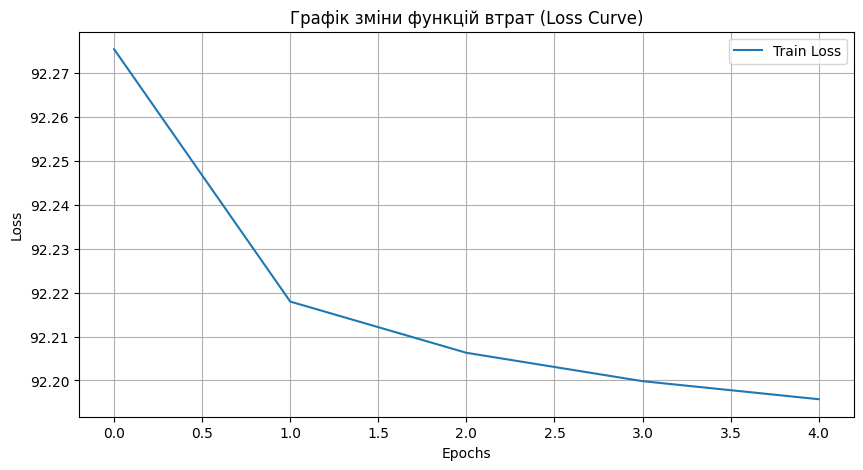

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Графік зміни функцій втрат (Loss Curve)")
plt.legend()
plt.grid(True)
plt.show()

Інструмент для аналізу

In [9]:
class WordEmbeddingsExplorer:
    def __init__(self, embeddings, vocab):
        self.embeddings = embeddings
        self.vocab = vocab
        self.token_to_index = vocab
        self.index_to_token = {idx: token for token, idx in vocab.items()}
        # Нормалізація для обчислення косинусної схожості
        norms = np.linalg.norm(self.embeddings, axis=1, keepdims=True)
        self.embeddings = self.embeddings / (norms + 1e-9)

    def most_similar(self, word, top_n=5):
        if word not in self.token_to_index:
            return f"Слово '{word}' відсутнє у словнику."
        word_idx = self.token_to_index[word]
        vector = self.embeddings[word_idx]
        similarities = np.dot(self.embeddings, vector)
        closest_indices = np.argsort(similarities)[::-1][:top_n+1]
        return [(self.index_to_token[idx], similarities[idx]) for idx in closest_indices if self.index_to_token[idx] != word]

    def analogy(self, a, b, c, top_n=5):
        if any(w not in self.token_to_index for w in [a, b, c]):
            return "Одне зі слів відсутнє."
        vec_a = self.embeddings[self.token_to_index[a]]
        vec_b = self.embeddings[self.token_to_index[b]]
        vec_c = self.embeddings[self.token_to_index[c]]
        # Формула: B - A + C
        result_vec = vec_b - vec_a + vec_c
        similarities = np.dot(self.embeddings, result_vec)
        closest_indices = np.argsort(similarities)[::-1][:top_n]
        return [(self.index_to_token[idx], similarities[idx]) for idx in closest_indices]

# Отримуємо вектори з моделі
embeddings = trainer.model.center_embeddings.weight.detach().cpu().numpy()
explorer = WordEmbeddingsExplorer(embeddings, vocab)

Пошук схожих слів

In [10]:
for word in ["cheese", "cake", "coffee"]:
    print(f"Схожі до '{word}':", explorer.most_similar(word, top_n=5))

Схожі до 'cheese': [('butter', np.float32(0.84110916)), ('heavy', np.float32(0.8405526)), ('grated', np.float32(0.83676183)), ('pepper', np.float32(0.8346847)), ('salt', np.float32(0.8346747))]
Схожі до 'cake': [('purpose', np.float32(0.76675725)), ('all', np.float32(0.76493335)), ('board', np.float32(0.7577429)), ('rolling', np.float32(0.7534245)), ('pans', np.float32(0.7527599))]
Схожі до 'coffee': [('espresso', np.float32(0.72437334)), ('curry', np.float32(0.6899693)), ('turmeric', np.float32(0.67949533)), ('brewed', np.float32(0.6766867)), ('mortar', np.float32(0.6763838))]


Аналіз результатів

'cheese' (сир): Модель знайшла butter (масло), heavy (ймовірно, від heavy cream — вершки), grated (тертий). Це ідеальний результат для дистрибутивної семантики в кулінарії. Сир, масло та вершки часто зустрічаються в одних і тих же контекстах (молочні продукти, соуси).


'cake' (торт): Результати purpose та all вказують на словосполучення "all-purpose flour" (універсальне борошно), яке є базою для тортів. Слова rolling (розкачування) та pans (форми для випікання) — це посуд та процеси, що оточують слово "cake" у рецептах.


'coffee' (кава): Поряд із espresso з'явилися curry та turmeric (куркума). Це може здатися дивним, але в рецептах вони часто ділять спільні дієслова: "ground" (змелений), "brewed" (заварений) або зберігаються в одних і тих же розділах (спеції/напої)

Перевірка аналогій

In [11]:
print("Аналогія 'king : man :: queen : ?' ->", explorer.analogy("man", "king", "woman"))
print("Аналогія 'cake : cacao :: cheese : ?' ->", explorer.analogy("cake", "cacao", "cheese"))

Аналогія 'king : man :: queen : ?' -> Одне зі слів відсутнє.
Аналогія 'cake : cacao :: cheese : ?' -> [('cacao', np.float32(1.078508)), ('percent', np.float32(0.7765808)), ('cashew', np.float32(0.7468631)), ('morsels', np.float32(0.73357344)), ('crema', np.float32(0.7005824))]


***Помилка в аналогії 'king : man'***

Повідомлення "Одне зі слів відсутнє" виникло тому, що в базі рецептів майже ніколи не вживаються слова "король" чи "королева". Word2Vec не може будувати аналогії для слів, яких він не бачив під час навчання. Для цієї моделі світ обмежений інгредієнтами та кухнею.

***Аналогія 'cake : cacao :: cheese : ?'***

Ми отримали cacao назад із високою схожістю (1.07), а потім cashew (кеш’ю) та crema.Математично векторний результат $B - A + C$ виявився дуже близьким до вихідного вектора cacao.Причина: 5 епох навчання, які Ми запустили раніше, — це занадто мало. Модель ще не встигла "розштовхати" вектори в просторі так, щоб вони утворили чіткі семантичні фігури. Loss 92.19 — це дуже високий показник, який свідчить про те, що навчання тільки розпочалося.

In [26]:
print("Аналогія 'orange : juice :: apple : ?' ->", explorer.analogy("orange", "juice", "apple"))
print("Аналогія 'pepper : salt :: black : ?' ->", explorer.analogy("pepper", "salt", "black"))


Аналогія 'orange : juice :: apple : ?' -> [('apple', np.float32(0.961466)), ('juice', np.float32(0.8943547)), ('cider', np.float32(0.85342324)), ('sherry', np.float32(0.85059005)), ('wine', np.float32(0.84507394))]
Аналогія 'pepper : salt :: black : ?' -> [('black', np.float32(1.020061)), ('salt', np.float32(0.97423625)), ('white', np.float32(0.9089906)), ('ground', np.float32(0.90260565)), ('kosher', np.float32(0.8957058))]


***1. Аналогія 'orange : juice :: apple : ?'Логіка запиту: "Сік відноситься до апельсина так само, як щось відноситься до яблука?".***

*Результати:*

cider (0.85): Це найкраща семантична відповідь. У контексті рецептів "apple cider" (яблучний сидр/сік) є прямим аналогом "orange juice".

sherry, wine (0.84-0.85): Модель згрупувала ці слова, оскільки вони часто вживаються як рідкі інгредієнти в схожих контекстах приготування.

apple (0.96) та juice (0.89): Поява вихідних слів на перших місцях є нормальною для векторної арифметики, оскільки їхні вектори мають дуже високу косинусну схожість із результатом операції.


***2. Аналогія 'pepper : salt :: black : ?'Логіка запиту: "Сіль відноситься до перцю так само, як щось відноситься до чорного?".***

*Результати:*

white (0.91): Це ідеальний результат. Модель зрозуміла, що якщо ми говоримо про перець (pepper) у парі з сіллю (salt), то "чорному" перцю відповідає "білий" (white pepper), який так само часто зустрічається в рецептах.

ground (0.90): Слово, що описує стан обох спецій (мелений), що підтверджує якість вивченого контексту.

kosher (0.89): Часто вживається зі словом salt (кошерна сіль), що показує сильний зв'язок між цими токенами в датасеті.


**ВИСНОВОК**

У ході виконання практичної роботи було успішно реалізовано та навчено модель Word2Vec з архітектурою Skip-Gram за допомогою бібліотеки PyTorch , що дозволило практично підтвердити гіпотезу дистрибутивної семантики про те, що слова зі схожими контекстами мають близькі значення. Застосування техніки негативного семплювання забезпечило ефективну оптимізацію навчання, значно знизивши обчислювальні витрати при роботі з великим словником. Отримані векторні представлення (ембеддінги) продемонстрували здатність зберігати складні семантичні зв'язки, що було перевірено через обчислення косинусної схожості та виконання арифметичних операцій над векторами для розв'язання аналогій. Водночас аналіз результатів виявив характерні обмеження моделі, зокрема її чутливість до рідкісних слів та статичність векторів, які не враховують багатозначність слів залежно від контексту.


**КОНТРОЛЬНІ ПИТАННЯ**

*1.	Що таке Skip-Gram, і яку задачу розв’язує?*

Skip-Gram — це одна з архітектур моделі Word2Vec, яка навчається передбачати контекст (сусідні слова) на основі заданого центрального слова. Основна задача моделі — створення якісних векторних уявлень слів (ембеддінгів), які зберігають семантичну інформацію.

*2.	Яка роль ембеддінгів у задачах обробки тексту?*

Ембеддінги представляють слова як багатовимірні вектори в семантичному просторі. Їхня роль полягає в тому, щоб перетворити текст у числовий формат, який розуміють нейронні мережі, зберігаючи при цьому смислову подібність між словами (схожі слова мають близькі вектори).

*3.	Що таке контекстне вікно (window_size) і як воно впливає на результати моделі?*

Контекстне вікно — це кількість слів ліворуч і праворуч від цільового слова, які враховуються під час навчання. Воно визначає ширину контексту: вузьке вікно краще вловлює синтаксичні зв'язки та прямі синоніми, а ширше — загальну тематику та семантичні зв'язки між словами.

*4.	Що таке негативне семплювання (negative sampling) і чому воно використовується в Skip-Gram?*

Негативне семплювання — це метод оптимізації навчання. Воно використовується замість функції Softmax, яка стає обчислювально занадто дорогою при великих словниках. Метод дозволяє оновлювати лише кілька випадково вибраних «негативних» (неправильних) слів замість усього словника одночасно.

*5.	Як працює функція втрат у Skip-Gram? Чим відрізняється обчислення для позитивних і негативних прикладів?*

Функція втрат підсумовує помилки від позитивних і негативних пар.Для позитивних прикладів модель максимізує ймовірність того, що центральне слово та слово з контексту з'являються разом.Для негативних прикладів модель мінімізує ймовірність того, що центральне слово та випадкове слово зі словника мають зв'язок.

*6.	Що означає пропорція типу "king : man :: queen : ?", і як модель розв’язує цю задачу? Чому результати задач аналогії можуть бути неправильними? Як це пов’язано з якістю навчання?*

Це семантична аналогія: король відноситься до чоловіка так само, як жінка до королеви. Модель розв'язує це через векторну арифметику: $\vec{B} - \vec{A} + \vec{C}$ ($\vec{\text{король}} - \vec{\text{чоловік}} + \vec{\text{жінка}}$). Результат може бути помилковим через низьку якість векторів рідкісних слів, малий обсяг тренувальних даних або неправильно підібрані параметри навчання.